In [1]:
import torch
from src.evaluator import ShadeEvaluator
from datetime import datetime
import pandas as pd

from src.visualization import plot_losses

In [2]:
# Instantiate Evaluator
RESULTS_DIR = "../results/test_all_10_epoch/"
CHECKPOINT_PATH = "../results/test_all_10_epoch/results/checkpoint.ckpt"
device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
else "cpu")
print(device)

evaluator = ShadeEvaluator(device, CHECKPOINT_PATH, RESULTS_DIR)

Seed set to 42


mps
Model initialized...


In [4]:
# Test evaluation
# test_tile = "/Users/luc/Geomatics/Thesis/testing_data/271110/input/271110_p_403_2022_06_02_dsm.tif"
test_tile = "/Users/luc/Geomatics/Thesis/training_data/271110/input/271110_p_189_2022_06_02_dsm.tif"
date_time = datetime(2024, 5, 15, 17, 30, 0, 0)
evaluator.generate_and_write_output(test_tile, date_time, overlap=64, crop=True, strategy="max", filename="hello")

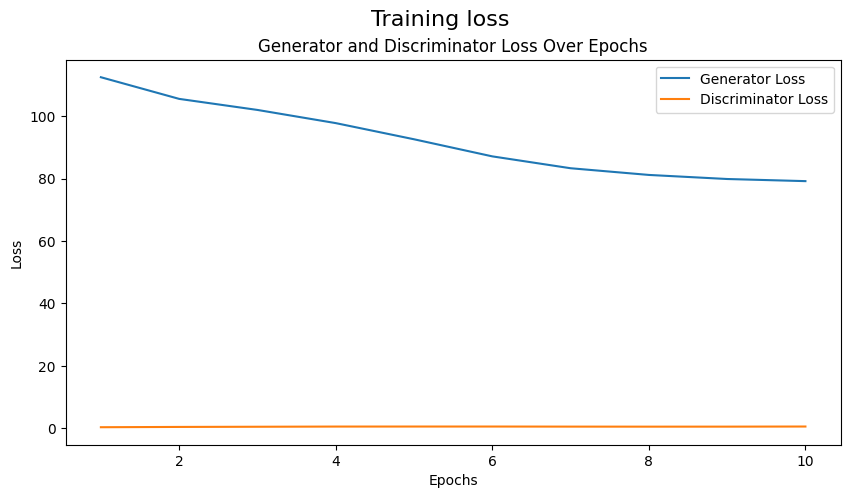

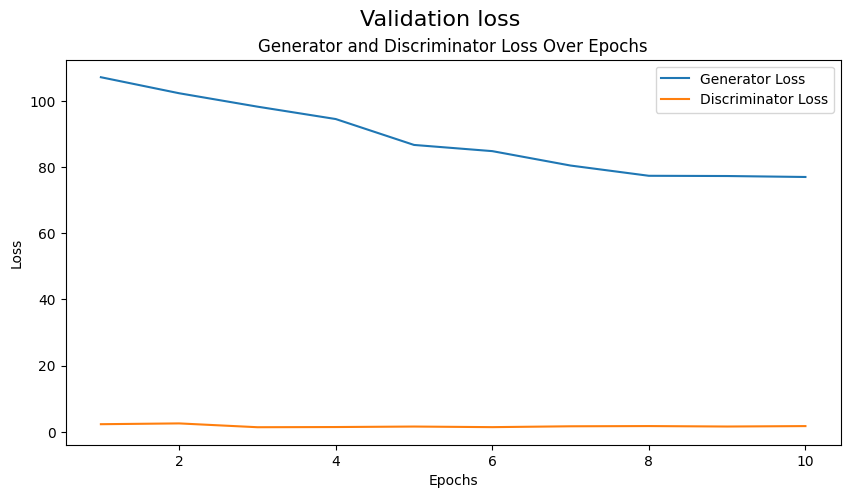

In [6]:
df = pd.read_csv("/Users/luc/Geomatics/Thesis/ShadyShenanigans/results/test_all_10_epoch/results/loss_logs/version_0/metrics.csv")

g_train = df["train_g_losses"]
d_train = df["train_d_losses"]
g_val = df["val_g_losses"]
d_val = df["val_d_losses"]

plot_losses(g_train, d_train, title="Training loss")
plot_losses(g_val, d_val, title="Validation loss")

# METRICS

In [4]:
TEST_DATA_PATH = "/Users/luc/Geomatics/Thesis/training_data/"
CSV_PATH = "/Users/luc/Geomatics/Thesis/ShadyShenanigans/results"

evaluator.write_metrics_csv(TEST_DATA_PATH, CSV_PATH)

Processing city with osmid: 271110
Writing for tile: 189...
Skipped 47 due to zenith < 15 degrees
Writing for tile: 175...
Skipped 47 due to zenith < 15 degrees
Writing for tile: 176...
Skipped 47 due to zenith < 15 degrees
Writing for tile: 190...
Skipped 47 due to zenith < 15 degrees
Processing city with osmid: 1251066
Writing for tile: 3...
Skipped 0 due to zenith < 15 degrees
